# Data Analysis (qubit_TransmonCross_cap_matrix)
## Qiskit Metal --> Capacitance

Ansys surrogate model

## Configuration

Disable cell scrolling.

The parameter file is where the hyperparameters are set. It's reccomended to look at that file first, its interesting and you can set stuff there

In [1]:
from parameters_surrogate import *

In [2]:
# make directory for data and scaler saving
os.makedirs('scalers', exist_ok=True)
os.makedirs(f'{DATA_DIR}', exist_ok=True)
os.makedirs(f'{DATA_DIR}/npy', exist_ok=True)

## Library

In [3]:
import json
import numpy as np
import pandas as pd
from pandas import json_normalize
import joblib
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

2026-03-09 17:45:01.333491: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Datasets

### Load
From https://huggingface.co/datasets/SQuADDS/SQuADDS_DB/tree/main

In [4]:
df = pd.read_json("qubit-TransmonCross-cap_matrix.json")

### Look at the data and structure

In [5]:
#look at the first value
first_entry = df.iloc[100]

# Print the headers and their corresponding values
for header, value in first_entry.items():
    print(f"{header}: {value}")

sim_results: {'cross_to_ground': 155.21897, 'claw_to_ground': 63.04611, 'cross_to_claw': 1.83606, 'cross_to_cross': 155.21897, 'claw_to_claw': 65.18175, 'ground_to_ground': 279.3005, 'units': 'fF'}
sim_options: {'setup': {'name': 'sweep_setup', 'reuse_selected_design': False, 'reuse_setup': False, 'freq_ghz': 5.0, 'save_fields': False, 'enabled': True, 'max_passes': 30, 'min_passes': 2, 'min_converged_passes': 1, 'percent_error': 0.1, 'percent_refinement': 30, 'auto_increase_solution_order': True, 'solution_order': 'High', 'solver_type': 'Iterative', 'run': {'name': 'sweep_v2.0', 'components': ['Q'], 'open_terminations': [['Q', 'readout']], 'box_plus_buffer': True}}, 'renderer_options': {'Lj': '10nH', 'Cj': 0, '_Rj': 0, 'max_mesh_length_jj': '7um', 'max_mesh_length_port': '7um', 'project_path': None, 'project_name': None, 'design_name': None, 'x_buffer_width_mm': 0.2, 'y_buffer_width_mm': 0.2, 'wb_threshold': '400um', 'wb_offset': '0um', 'wb_size': 5, 'plot_ansys_fields_options': {'nam

In [6]:
#Look at the headers relevant for us, to start lets only look at the sim_results (our x data) and design (our y data)
sim_results_column = df['sim_results']
print(sim_results_column, '\n\n')

design_column = df['design']
print(design_column)

0       {'cross_to_ground': 158.40783, 'claw_to_ground...
1       {'cross_to_ground': 188.15089, 'claw_to_ground...
2       {'cross_to_ground': 104.3534, 'claw_to_ground'...
3       {'cross_to_ground': 174.13928, 'claw_to_ground...
4       {'cross_to_ground': 120.03923, 'claw_to_ground...
                              ...                        
1929    {'cross_to_ground': 174.4638, 'claw_to_ground'...
1930    {'cross_to_ground': 187.43537, 'claw_to_ground...
1931    {'cross_to_ground': 172.14561, 'claw_to_ground...
1932    {'cross_to_ground': 56.7523, 'claw_to_ground':...
1933    {'cross_to_ground': 62.01, 'claw_to_ground': 5...
Name: sim_results, Length: 1934, dtype: object 


0       {'design_options': {'pos_x': '-1500um', 'pos_y...
1       {'design_options': {'pos_x': '-1500um', 'pos_y...
2       {'design_options': {'pos_x': '-1500um', 'pos_y...
3       {'design_options': {'pos_x': '-1500um', 'pos_y...
4       {'design_options': {'pos_x': '-1500um', 'pos_y...
                      

In [7]:
#take a look at everything in the design dataset
# Flatten the design column
design_flat = json_normalize(df['design'])

# List all column headers
design_column_vals = design_flat.columns.tolist()
print(design_column_vals)
print('length: ',len(design_column_vals))

['design_tool', 'design_options.pos_x', 'design_options.pos_y', 'design_options.orientation', 'design_options.chip', 'design_options.layer', 'design_options.connection_pads.readout.connector_type', 'design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.connection_pads.readout.claw_width', 'design_options.connection_pads.readout.claw_gap', 'design_options.connection_pads.readout.claw_cpw_length', 'design_options.connection_pads.readout.claw_cpw_width', 'design_options.connection_pads.readout.connector_location', 'design_options.cross_width', 'design_options.cross_length', 'design_options.cross_gap', 'design_options.hfss_inductance', 'design_options.hfss_capacitance', 'design_options.hfss_resistance', 'design_options.hfss_mesh_kw_jj', 'design_options.q3d_inductance', 'design_options.q3d_capacitance', 'design_options.q3d_resistance', 'design_options.q3d_mesh_kw_jj', 'design_options.gds_cell_name', 'design_options.aedt

### Reformat

In [8]:
#flatten what will be our capacitance data (Model 1's X, Model 2's Y)
X_cap = json_normalize(df['sim_results'])
# Dropping the 'units' column for now because they are all in fF and this info isnt useful
X_cap = X_cap.drop(columns=['units'])
print(X_cap)

      cross_to_ground  claw_to_ground  cross_to_claw  cross_to_cross  \
0           158.40783        90.86585        3.73363       158.40783   
1           188.15089        79.19378        2.93820       188.15089   
2           104.35340        80.18130        3.16131       104.35340   
3           174.13928        97.22405        5.77590       174.13928   
4           120.03923        65.68607        2.87375       120.03923   
...               ...             ...            ...             ...   
1929        174.46380       101.53197        4.45645       174.46380   
1930        187.43537       112.62570        7.95178       187.43537   
1931        172.14561       136.36810        7.65968       172.14561   
1932         56.75230        65.78116        2.48795        56.75230   
1933         62.01000        55.50796        2.54396        62.01000   

      claw_to_claw  ground_to_ground  
0         94.97421         311.25590  
1         82.44280         333.52997  
2         83.76412

In [9]:
# Flatten the Qiskit Metal design parameters 
y_design = json_normalize(df['design'])

columns_to_drop = ['design_tool', 'design_options.pos_x', 'design_options.pos_y',
       'design_options.orientation', 'design_options.chip',
       'design_options.layer',
       'design_options.connection_pads.readout.connector_type',
       'design_options.connection_pads.readout.claw_width',
       'design_options.connection_pads.readout.claw_gap',
       'design_options.connection_pads.readout.claw_cpw_length',
       'design_options.connection_pads.readout.claw_cpw_width',
       'design_options.connection_pads.readout.connector_location',
       'design_options.cross_width',
       'design_options.cross_gap', 'design_options.hfss_inductance',
       'design_options.hfss_capacitance', 'design_options.hfss_resistance',
       'design_options.hfss_mesh_kw_jj', 'design_options.q3d_inductance',
       'design_options.q3d_capacitance', 'design_options.q3d_resistance',
       'design_options.q3d_mesh_kw_jj', 'design_options.gds_cell_name',
       'design_options.aedt_q3d_inductance',
       'design_options.aedt_q3d_capacitance',
       'design_options.aedt_hfss_inductance',
       'design_options.aedt_hfss_capacitance']

#get rid of this column because there are two spellings in the dataset that will confuse the NN.
#We always just use Qiskit, so for now we dont need this
y_design = y_design.drop(columns=columns_to_drop)

print(f'y_design shape: {y_design.shape}')
print(y_design)

y_design shape: (1934, 3)
     design_options.connection_pads.readout.claw_length  \
0                                                 160um   
1                                                 120um   
2                                                 130um   
3                                                 180um   
4                                                  90um   
...                                                 ...   
1929                                              190um   
1930                                              240um   
1931                                              280um   
1932                                               90um   
1933                                               70um   

     design_options.connection_pads.readout.ground_spacing  \
0                                                  10um      
1                                                 9.1um      
2                                                  10um      
3                

### Validate and View Data

In [10]:
display(X_cap)

,cross_to_ground,claw_to_ground,cross_to_claw,cross_to_cross,claw_to_claw,ground_to_ground
0,158.40783,90.86585,3.73363,158.40783,94.97421,311.25590
1,188.15089,79.19378,2.93820,188.15089,82.44280,333.52997
2,104.35340,80.18130,3.16131,104.35340,83.76412,237.02548
3,174.13928,97.22405,5.77590,174.13928,103.37057,335.31609
4,120.03923,65.68607,2.87375,120.03923,68.92854,240.34085
...,...,...,...,...,...,...
1929,174.46380,101.53197,4.45645,174.46380,106.43025,340.62919
1930,187.43537,112.62570,7.95178,187.43537,121.10943,367.34003
1931,172.14561,136.36810,7.65968,172.14561,144.56289,372.39970
1932,56.75230,65.78116,2.48795,56.75230,68.76413,166.57383


In [11]:
display(y_design)

,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
0,160um,10um,310um
1,120um,9.1um,350um
2,130um,10um,210um
3,180um,5um,330um
4,90um,5um,230um
...,...,...,...
1929,190um,10um,340um
1930,240um,4.1um,370um
1931,280um,9.1um,330um
1932,90um,10um,120um


## Transform Y to Numerical Values

We need all columns to be numeric floats for the MLP. This means stripping units like 'um' and 'nH',
converting to SI, and filling NaNs.

In [12]:
#look at the format all of the y values are in
for col in y_design.columns:
    print(f"{col}  {y_design[col].iloc[0]}")
print(y_design.shape)

design_options.connection_pads.readout.claw_length  160um
design_options.connection_pads.readout.ground_spacing  10um
design_options.cross_length  310um
(1934, 3)


In [13]:
y_numerical = y_design.copy()

In [14]:
# Strip units (um, nH) and convert to SI
y_numerical_clean = y_numerical.copy()

# Extract numerical values and convert units (assuming 'um' for some columns)
um_cols = [col for col in y_numerical_clean.columns if y_numerical_clean[col].astype(str).str.contains('um').any()]

for col in um_cols:
    y_numerical_clean[col] = pd.to_numeric(y_numerical_clean[col].astype(str).str.replace('um', '', regex=False), errors='coerce') * 1e-6
    y_numerical_clean[col] = y_numerical_clean[col].round(15)

nH_cols = [col for col in y_numerical_clean.columns if y_numerical_clean[col].astype(str).str.contains('nH').any()]
for col in nH_cols:
    y_numerical_clean[col] = pd.to_numeric(y_numerical_clean[col].astype(str).str.replace('nH', '', regex=False), errors='coerce') * 1e-9
    y_numerical_clean[col] = y_numerical_clean[col].round(15)

for col in y_numerical_clean.columns:
    try:
        print(f"{col}-----------Numerical: {y_numerical_clean[col].iloc[0]}-----------Original: {y_design[col].iloc[0]}")
    except KeyError:
        print(f'{col} -- changed')

design_options.connection_pads.readout.claw_length-----------Numerical: 0.00016-----------Original: 160um
design_options.connection_pads.readout.ground_spacing-----------Numerical: 1e-05-----------Original: 10um
design_options.cross_length-----------Numerical: 0.00031-----------Original: 310um


In [15]:
# Print how many columns have NaN in them
for col in y_design.columns:
    total = len(y_design[col])
    n_nan = y_design[col].isna().sum()
    if 0 < n_nan < total:
        pct_nan = n_nan / total * 100
        zero_mask = y_design[col].astype(str).str.contains('0.0', na=False)
        n_zero = zero_mask.sum()
        pct_zero = n_zero / total * 100
        print(f"{col}:")
        print(f"  NaN values:  {n_nan}/{total}  ({pct_nan:.2f}%)")
        print(f"  '0.0' vals:  {n_zero}/{total}  ({pct_zero:.2f}%)")
        print()

In [16]:
# Fill NaN with 1 (same as original notebook)
y_numerical_clean.fillna(float(1), inplace=True)

print('Now all of these should be numerical:')
for col in y_numerical_clean.columns:
    print(f"{col}-----------{y_numerical_clean[col].iloc[0]}")

Now all of these should be numerical:
design_options.connection_pads.readout.claw_length-----------0.00016
design_options.connection_pads.readout.ground_spacing-----------1e-05
design_options.cross_length-----------0.00031


In [17]:
y_final = y_numerical_clean.copy()
print('Final y shape:', y_final.shape)
display(y_final)

Final y shape: (1934, 3)


,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
0,0.00016,0.000010,0.00031
1,0.00012,0.000009,0.00035
2,0.00013,0.000010,0.00021
3,0.00018,0.000005,0.00033
4,0.00009,0.000005,0.00023
...,...,...,...
1929,0.00019,0.000010,0.00034
1930,0.00024,0.000004,0.00037
1931,0.00028,0.000009,0.00033
1932,0.00009,0.000010,0.00012


### Save the header names of the y data

In [18]:
filename = 'y_characteristics_linear_encoding.csv'
headers = list(y_final.columns)
with open(filename, 'w') as f:
    f.write(','.join(headers))
print(f'Saved {filename} with {len(headers)} columns')

Saved y_characteristics_linear_encoding.csv with 3 columns


## Visualize

### X Data (Capacitance values)

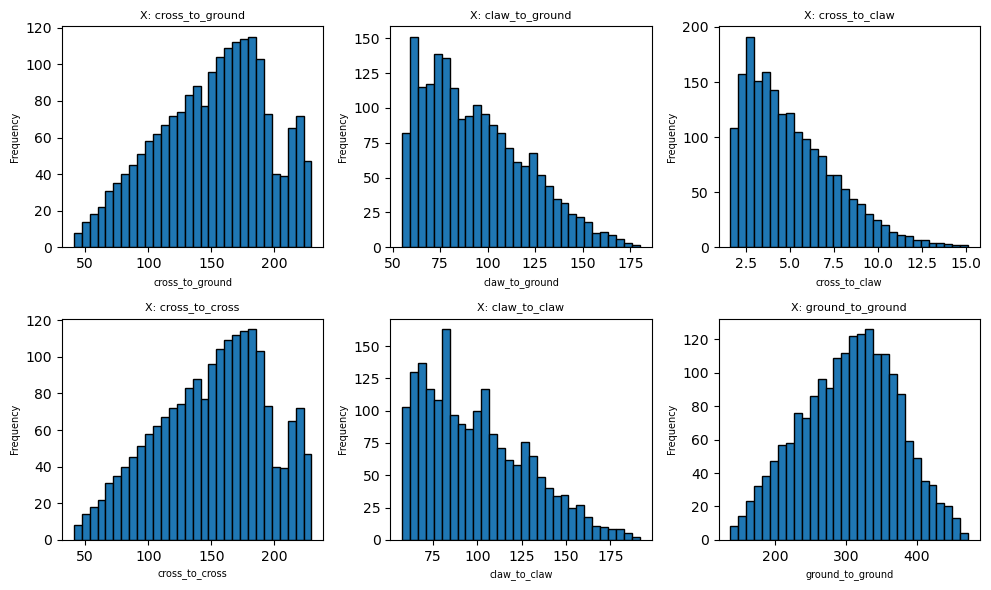

In [19]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_cap.columns):
    axes[i].hist(X_cap[col], bins=30, edgecolor='black')
    axes[i].set_title(f'X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_x_cap_distribution.pdf')
plt.show()

### Y Data (Qiskit Metal params)

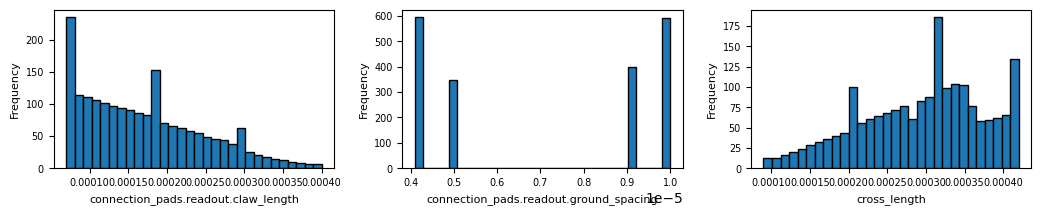

In [20]:
num_cols = len(y_final.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for n, col in enumerate(y_final.columns):
    try:
        plt.subplot(num_rows, 4, n + 1)
        plt.hist(y_final[col], bins=30, edgecolor='black')
        plt.xlabel(col.split('design_options.')[-1], fontsize=8)
        plt.ylabel('Frequency', fontsize=8)
        plt.tick_params(axis='both', which='major', labelsize=7)
    except TypeError:
        print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")

plt.tight_layout()
plt.savefig('plots/model2_unscaled_y_design_distribution.png')
plt.show()

In [21]:
plt.close()

## Split

Dataset split is 70%-15%-15% training-validation-test. We use a constant state (seed) for reproducible splits.

In [22]:
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_cap, y_final, test_size=0.3, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, random_state=42, shuffle=True
)

In [23]:
total = y_train.shape[0] + y_test.shape[0] + y_val.shape[0]
print('---------------------------------------')
print('Train set shape: {}, {:.2f}%'.format(y_train.shape, (y_train.shape[0]*100.)/total))
print('Validation set shape: {}, {:.2f}%'.format(y_val.shape, (y_val.shape[0]*100.)/total))
print('Test set shape: {}, {:.2f}%'.format(y_test.shape, (y_test.shape[0]*100.)/total))
print('---------------------------------------')

---------------------------------------
Train set shape: (1353, 3), 69.96%
Validation set shape: (290, 3), 14.99%
Test set shape: (291, 3), 15.05%
---------------------------------------


## Augment

### Scale X (Capacitance values)

Scale capacitance values to be between 0 and 1

In [24]:
def scale_splits_per_column(train_df, val_df, test_df, scaler_name_prefix):
    train_s = train_df.copy()
    val_s   = val_df.copy()
    test_s  = test_df.copy()

    scalers = {}
    for col in train_df.columns:
        sc = MinMaxScaler()
        sc.fit(train_df[[col]])

        train_s[col] = sc.transform(train_df[[col]])
        val_s[col]   = sc.transform(val_df[[col]])
        test_s[col]  = sc.transform(test_df[[col]])

        scalers[col] = sc
        joblib.dump(sc, f'scalers/{scaler_name_prefix}_{col}.save')

    return train_s, val_s, test_s, scalers

X_train_scaled, X_val_scaled, X_test_scaled, x_scalers = scale_splits_per_column(
    X_train, X_val, X_test,
    scaler_name_prefix='scaler_X_linear'
)

In [25]:
# look at the scaled stuff to check
display(X_train_scaled.head())
display(X_val_scaled.head())
display(X_test_scaled.head())

,cross_to_ground,claw_to_ground,cross_to_claw,cross_to_cross,claw_to_claw,ground_to_ground
745,0.795623,0.166742,0.191337,0.795623,0.170240,0.584535
1442,0.935446,0.111205,0.036703,0.935446,0.102137,0.650090
937,0.569042,0.076383,0.031074,0.569042,0.069867,0.398249
493,0.781753,0.134819,0.063814,0.781753,0.127406,0.560550
1271,0.296035,0.025724,0.055608,0.296035,0.025232,0.199639


,cross_to_ground,claw_to_ground,cross_to_claw,cross_to_cross,claw_to_claw,ground_to_ground
1856,0.589019,0.535819,0.606316,0.589019,0.556489,0.589131
832,0.645303,0.664730,0.705917,0.645303,0.687066,0.671510
1393,0.629034,0.164587,0.085033,0.629034,0.157737,0.470574
483,0.383621,0.082486,0.098859,0.383621,0.082594,0.278708
1023,0.481764,0.404106,0.464210,0.481764,0.419514,0.468378


,cross_to_ground,claw_to_ground,cross_to_claw,cross_to_cross,claw_to_claw,ground_to_ground
1547,0.486726,0.332857,0.333689,0.486726,0.339616,0.442740
1890,0.568657,0.118193,0.051998,0.568657,0.111141,0.415697
1009,0.239722,0.109517,0.165374,0.239722,0.114911,0.195275
613,0.345244,0.192985,0.205119,0.345244,0.196844,0.294791
715,0.202381,0.080307,0.111293,0.202381,0.082236,0.158240


### Scale Y (Qiskit Metal params)

In [26]:
y_train_scaled, y_val_scaled, y_test_scaled, y_scalers = scale_splits_per_column(
    y_train, y_val, y_test,
    scaler_name_prefix='scaler_y_linear'
)

In [27]:
# look at the scaled stuff to check
display(y_train_scaled.head())
display(y_val_scaled.head())
display(y_test_scaled.head())

,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
745,0.181818,0.000000,0.848485
1442,0.060606,1.000000,0.939394
937,0.030303,0.847458,0.575758
493,0.090909,0.847458,0.787879
1271,0.000000,0.152542,0.303030


,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
1856,0.606061,0.000000,0.666667
832,0.696970,0.152542,0.696970
1393,0.121212,0.847458,0.636364
483,0.060606,0.152542,0.393939
1023,0.454545,0.000000,0.545455


,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
1547,0.333333,0.152542,0.515152
1890,0.090909,1.000000,0.606061
1009,0.121212,0.000000,0.272727
613,0.181818,0.152542,0.363636
715,0.060606,0.152542,0.212121


### Plot Scaled Data

### X

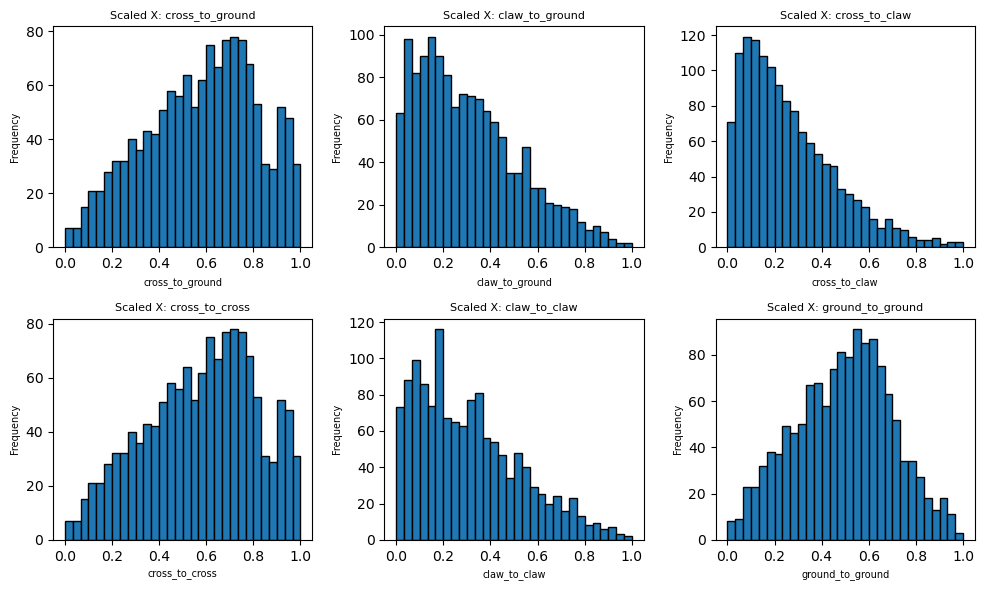

In [28]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_train_scaled.columns):
    axes[i].hist(X_train_scaled[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Scaled X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_scaled_x_cap_distribution.pdf')
plt.show()

### Y

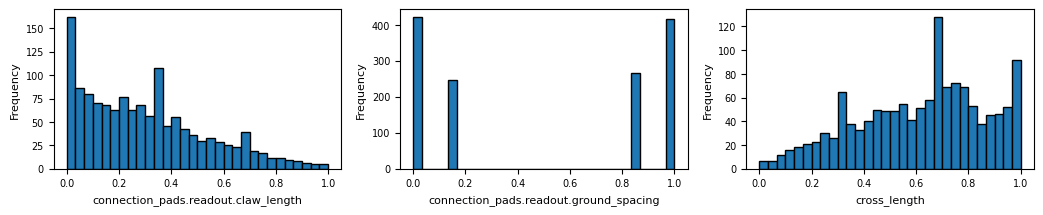

In [29]:
num_cols = len(y_train_scaled.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for n, col in enumerate(y_train_scaled.columns):
    try:
        plt.subplot(num_rows, 4, n + 1)
        plt.hist(y_train_scaled[col], bins=30, edgecolor='black')
        plt.xlabel(col.split('design_options.')[-1], fontsize=8)
        plt.ylabel('Frequency', fontsize=8)
        plt.tick_params(axis='both', which='major', labelsize=7)
    except TypeError:
        print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")

plt.tight_layout()
plt.savefig('plots/model2_scaled_y_design_distribution.png')
plt.show()

In [30]:
plt.close()

## Unscaling

To make sure we can recreate original values with saved scaler (compare with above cells)

### Unscale X

In [31]:
X_check = X_train_scaled
prefix = 'scaler_X_linear'

X_orig = X_check.copy()
for col in X_check.columns:
    sc = joblib.load(f'scalers/{prefix}_{col}.save')
    X_orig[col] = sc.inverse_transform(X_check[[col]])

display(X_orig.head())

,cross_to_ground,claw_to_ground,cross_to_claw,cross_to_cross,claw_to_claw,ground_to_ground
745,191.24712,75.97099,4.11475,191.24712,80.44307,334.80192
1442,217.37874,69.03981,2.08093,217.37874,71.32397,356.52886
937,148.90124,64.69381,2.00689,148.90124,67.00297,273.06018
493,188.65488,71.98696,2.43751,188.65488,74.70758,326.85219
1271,97.87873,58.37130,2.32958,97.87873,61.02640,207.23425


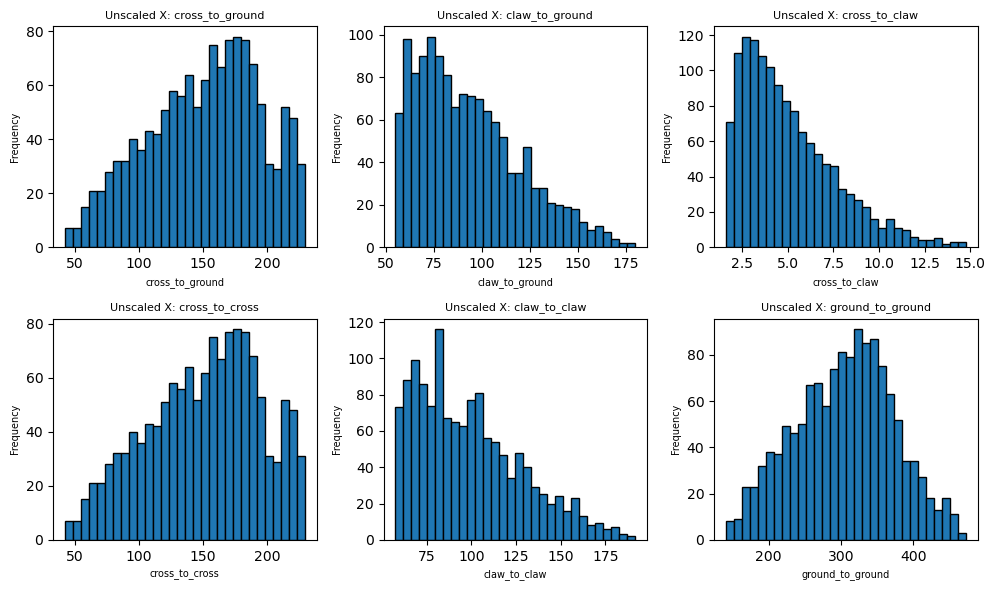

In [32]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_orig.columns):
    axes[i].hist(X_orig[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Unscaled X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_unscaled_x_check.pdf')
plt.show()

### Unscale Y

In [33]:
prefix = 'scaler_y_linear'
y_orig = y_train_scaled.copy()

for col in y_train_scaled.columns:
    sc = joblib.load(f'scalers/{prefix}_{col}.save')
    y_orig[col] = sc.inverse_transform(y_train_scaled[[col]])

display(y_orig.head())

,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
745,0.00013,0.000004,0.00037
1442,0.00009,0.000010,0.00040
937,0.00008,0.000009,0.00028
493,0.00010,0.000009,0.00035
1271,0.00007,0.000005,0.00019


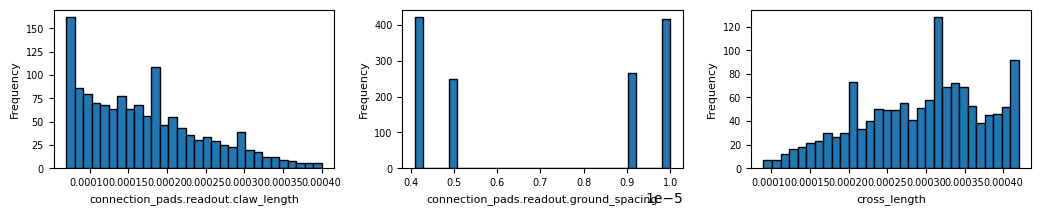

In [34]:
num_cols = len(y_orig.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for j, col in enumerate(y_orig.columns):
    plt.subplot(num_rows, 4, j + 1)
    plt.hist(y_orig[col], bins=30, edgecolor='black')
    plt.xlabel(col.split('design_options.')[-1], fontsize=8)
    plt.ylabel('Frequency', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=7)


plt.tight_layout()
plt.savefig('plots/model2_unscaled_y_check.png')
plt.show()

## Save

In [35]:
!rm -f $DATA_DIR/npy/*npy

In [36]:
# Unscaled
np.save(f'{DATA_DIR}/npy/x_train_linear_encoding.npy', X_train)
np.save(f'{DATA_DIR}/npy/x_val_linear_encoding.npy', X_val)
np.save(f'{DATA_DIR}/npy/x_test_linear_encoding.npy', X_test)

np.save(f'{DATA_DIR}/npy/y_train_linear_encoding.npy', y_train)
np.save(f'{DATA_DIR}/npy/y_val_linear_encoding.npy', y_val)
np.save(f'{DATA_DIR}/npy/y_test_linear_encoding.npy', y_test)

print(f'Unscaled data saved in: {DATA_DIR}/npy')

Unscaled data saved in: data/npy


In [37]:
# Scaled
np.save(f'{DATA_DIR}/npy/x_train_linear_encoding_scaled.npy', X_train_scaled)
np.save(f'{DATA_DIR}/npy/x_val_linear_encoding_scaled.npy',   X_val_scaled)
np.save(f'{DATA_DIR}/npy/x_test_linear_encoding_scaled.npy',  X_test_scaled)

np.save(f'{DATA_DIR}/npy/y_train_linear_encoding_scaled.npy', y_train_scaled)
np.save(f'{DATA_DIR}/npy/y_val_linear_encoding_scaled.npy',   y_val_scaled)
np.save(f'{DATA_DIR}/npy/y_test_linear_encoding_scaled.npy',  y_test_scaled)

print(f'Scaled data saved in: {DATA_DIR}/npy')

Scaled data saved in: data/npy


In [38]:
!ls $DATA_DIR/npy/*npy

data/npy/x_test_linear_encoding.npy
data/npy/x_test_linear_encoding_scaled.npy
data/npy/x_train_linear_encoding.npy
data/npy/x_train_linear_encoding_scaled.npy
data/npy/x_val_linear_encoding.npy
data/npy/x_val_linear_encoding_scaled.npy
data/npy/y_test_linear_encoding.npy
data/npy/y_test_linear_encoding_scaled.npy
data/npy/y_train_linear_encoding.npy
data/npy/y_train_linear_encoding_scaled.npy
data/npy/y_val_linear_encoding.npy
data/npy/y_val_linear_encoding_scaled.npy


In [39]:
# saving column names (where capacitance=X_names, Qiskit params=y_columns)
with open('X_names', 'w') as f:
    f.write('\n'.join(X_cap.columns))

np.save('y_columns.npy', np.array(y_train.columns))
print(f'Saved X_names ({len(X_cap.columns)} cols) and y_columns.npy ({len(y_train.columns)} cols)')

Saved X_names (6 cols) and y_columns.npy (3 cols)
